In [292]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
np.random.seed(0)

# Naïve Bayes

## Analyse & Visualisation Données

In [255]:
arbres = pd.read_csv("train.csv", index_col = 'ID_ARBRE')
prev = pd.read_csv("prev.csv", index_col = 'ID_ARBRE')
prev = prev[["type_sol", "classe_age", "classe_hauteur", "classe_circonference", "port_arbre", "vigueur_pousse", "plaie_collet", "fissure_tronc", "plaie_tronc", "fissure_houppier", "bois_mort_houppier", "plaie_houppier", "esperance_maintien"]]

In [257]:
x = arbres[["type_sol", "diametre", "hauteur", "classe_age", "classe_hauteur", "classe_circonference", "port_arbre", "vigueur_pousse", "plaie_collet", "fissure_tronc", "plaie_tronc", "fissure_houppier", "bois_mort_houppier", "plaie_houppier", "esperance_maintien"]]
y = arbres[["classification_diagnostic"]]

In [259]:
display(x.head(2))
display(y.head())

,type_sol,diametre,hauteur,classe_age,classe_hauteur,classe_circonference,port_arbre,vigueur_pousse,plaie_collet,fissure_tronc,plaie_tronc,fissure_houppier,bois_mort_houppier,plaie_houppier,esperance_maintien
ID_ARBRE,,,,,,,,,,,,,,,
0,MA,31.830989,500,A,H1,C1,R5,P,RCPPL,TPF,TPLS,HPF,HPBM,HPLS,1.0
1,MA,76.394373,800,A,H2,C3,R5,P,RCPLS,TFO,TPLNC,HFO,HPBM,HPLNC,2.0


,classification_diagnostic
ID_ARBRE,
0,C1
1,C4
2,C1
3,C2
4,C2


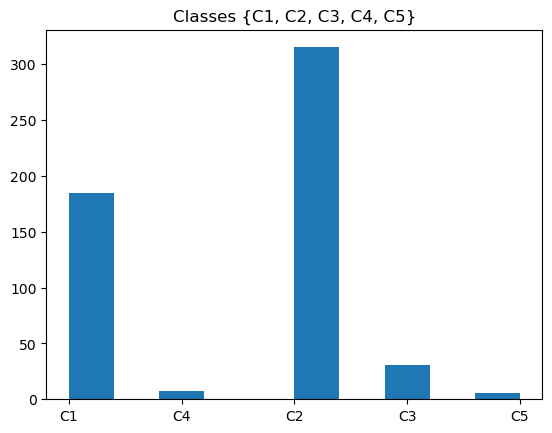

Proportions respectives par classe : 
[0.34007353 0.57904412 0.05698529 0.01286765 0.01102941]


In [223]:
plt.hist(y)
plt.title('Classes {C1, C2, C3, C4, C5}')
plt.show()

unique, counts = np.unique(y, return_counts = True)
print("Proportions respectives par classe : ")
print(counts/len(y))

In [284]:
def corr(x, y):
    x, y = np.array(x), np.array(y)
    mx, my = np.mean(x), np.mean(y)
    return np.sum((x-mx)*(y-my)) / (np.sqrt(np.sum((x-mx)**2)) * np.sqrt(np.sum((y-my)**2)))

corr(x['diametre'], x['hauteur'])

0.6821820682130718

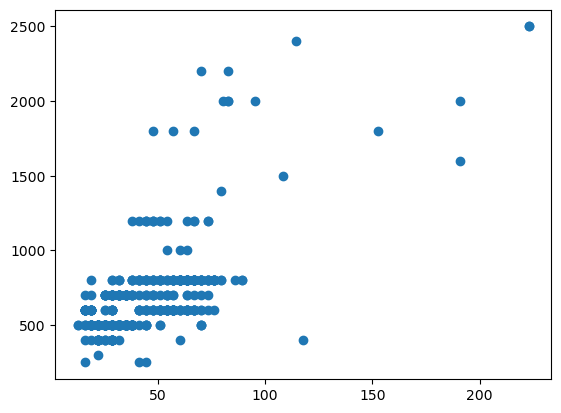

In [267]:
plt.scatter(x["diametre"], x["hauteur"])

(array([391.,   0.,   0., 110.,   0.,   0.,  39.,   0.,   0.,   4.]),
 array([1. , 1.3, 1.6, 1.9, 2.2, 2.5, 2.8, 3.1, 3.4, 3.7, 4. ]),
 <BarContainer object of 10 artists>)

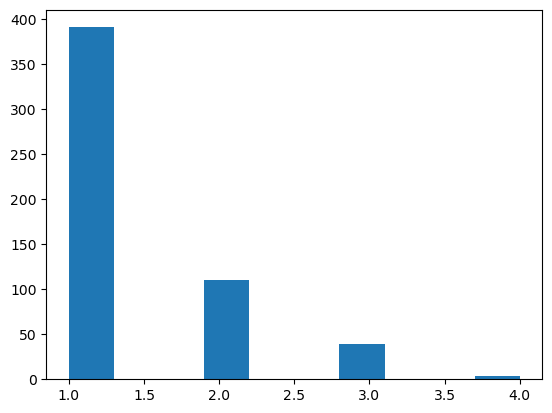

In [286]:
plt.hist(x["esperance_maintien"])

### Train_test_split 

In [225]:
from sklearn.model_selection import train_test_split

In [227]:
X_train, X_test, Y_train, Y_test = train_test_split(x, y, test_size = 0.2, random_state=42)

## Entraînement - Calculs Probas - Classifieur de Bayes

In [230]:
def log_proba_xsy(X, tab_val, Y):
    x_colonnes = X.columns
    y_unique = np.unique(Y)

    log_pxsy = []
    for c in y_unique:
        log_prob_c = 0 #Log probabilité de la classe Y=c
        for col, x_val in zip(x_colonnes, tab_val):
            num = np.sum((X[col] == x_val) & (Y["classification_diagnostic"] == c)) + 1  # Lissage de Laplace
            denom = np.sum(Y["classification_diagnostic"] == c) + len(np.unique(X[col])) 
            log_prob_c = log_prob_c + np.log(num / denom)  # Ajout du log de la probabilité conditionnelle
        log_pxsy.append(log_prob_c)
    return np.array(log_pxsy)

print(log_proba_xsy(x, x.iloc[0], y))

[ -8.02315196 -10.93974208 -14.60792874 -20.39423833 -23.27582546]


In [232]:
def proba_y(Y):
    y_unique = np.unique(Y)
    return [np.sum(Y["classification_diagnostic"]==c)/len(Y) for c in y_unique]

In [234]:
def log_proba_y(Y):
    y_unique, counts = np.unique(Y, return_counts=True)
    return np.log(counts / len(Y))

print(log_proba_y(y))

[-1.07859342 -0.54637661 -2.86496204 -4.3530391  -4.50718978]


In [236]:
def classifieur(X, tab_val, Y):
    y_unique = np.unique(Y)
    log_p_y = log_proba_y(Y)
    log_pxsy = log_proba_xsy(X, tab_val, Y)
    probas_ysx = log_pxsy + log_p_y
    
    return y_unique[np.argmax(probas_ysx)]

In [238]:
test_prediction = np.array([classifieur(X_train, X_test.iloc[i], Y_train) for i in range(len(X_test))])
test_prediction

array(['C2', 'C1', 'C1', 'C1', 'C3', 'C1', 'C1', 'C2', 'C1', 'C1', 'C2',
       'C1', 'C2', 'C2', 'C2', 'C1', 'C1', 'C2', 'C1', 'C1', 'C1', 'C1',
       'C1', 'C1', 'C2', 'C2', 'C2', 'C3', 'C2', 'C1', 'C2', 'C2', 'C2',
       'C2', 'C1', 'C1', 'C2', 'C1', 'C1', 'C2', 'C4', 'C1', 'C3', 'C1',
       'C2', 'C3', 'C1', 'C2', 'C2', 'C1', 'C2', 'C1', 'C1', 'C3', 'C1',
       'C1', 'C2', 'C1', 'C1', 'C2', 'C1', 'C3', 'C2', 'C3', 'C2', 'C2',
       'C1', 'C1', 'C1', 'C2', 'C2', 'C2', 'C1', 'C1', 'C2', 'C1', 'C2',
       'C1', 'C2', 'C1', 'C1', 'C1', 'C1', 'C1', 'C1', 'C1', 'C1', 'C1',
       'C1', 'C1', 'C1', 'C1', 'C1', 'C1', 'C2', 'C2', 'C2', 'C1', 'C2',
       'C1', 'C1', 'C1', 'C2', 'C2', 'C2', 'C2', 'C1', 'C2', 'C2'],
      dtype='<U2')

### Accuracy et Taux d'erreur

In [240]:
def taux_erreur(predict, y):
    erreurs = len([i for i, j in zip(predict, y.to_numpy()) if i != j])
    taux = np.round((erreurs / len(y)) * 100, 5)
    print(f"Taux d'erreur : {taux}%")

In [241]:
taux_erreur(test_prediction, Y_test)

Taux d'erreur : 29.3578%


In [242]:
def are(predict, Y):
    erreurs = len([i for i, j in zip(predict, Y.to_numpy().flatten()) if i == j])
    taux = np.round((erreurs / len(Y)) * 100, 5)
    #print(f"Average Classification Accuracy : {taux}%")
    return taux

In [243]:
are(test_prediction, Y_test)

70.6422

### Matrice de Confusion

In [155]:
def matrice_confusion(prediction, reality):
    # On a stack le vecteur des prédictions ŷ (à gauche) avec le vecteur des vraies valeurs y ("reality").
    stack_predict_et_y = np.vstack((prediction, reality["classification_diagnostic"])).T
    classes_y = np.unique(reality)
    confusion_matrix = np.zeros((len(classes_y), len(classes_y)), dtype = int)
    for i, c1 in enumerate(classes_y):
        for j, c2 in enumerate(classes_y):
            confusion_matrix[i][j] = np.sum((stack_predict_et_y[:, 0]==c2) & (stack_predict_et_y[:, 1]==c1))
    return confusion_matrix

matrice_confusion(test_prediction, Y_test)

array([[35, 11,  0,  0,  0],
       [11, 40,  3,  0,  0],
       [ 1,  2,  2,  0,  0],
       [ 0,  0,  2,  1,  0],
       [ 1,  0,  0,  0,  0]])

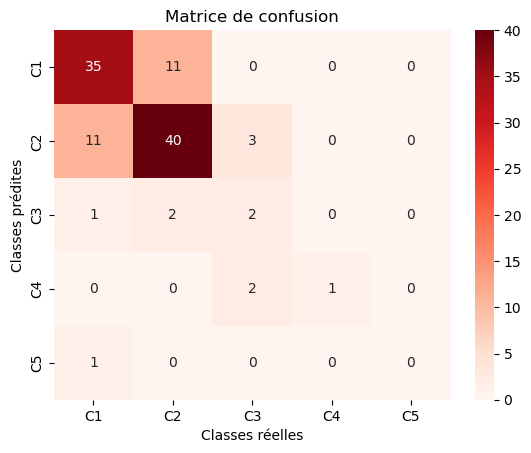

In [151]:
sns.heatmap(matrice_confusion(test_prediction, Y_test), annot=True, fmt="d", xticklabels=np.unique(y), yticklabels=np.unique(y), cmap="Reds")
plt.xlabel("Classes réelles")
plt.ylabel("Classes prédites")
plt.title("Matrice de confusion")
plt.show()

In [147]:
# On remarque qu'il y a 11 arbres C2 ayant été prédits C1. Cependant il n'y a aucun faux C5 (et heureusement...)

### Prédictions sur le dataset "Prev"

In [130]:
prev_prediction = np.array([classifieur(X_train, prev.iloc[i], Y_train) for i in range(len(prev))])
prev_prediction

array(['C2', 'C2', 'C2', 'C1', 'C3', 'C2', 'C2', 'C1', 'C2', 'C2', 'C5',
       'C1', 'C1', 'C2', 'C1', 'C1', 'C2', 'C2', 'C1', 'C3', 'C2', 'C3',
       'C1', 'C2', 'C1', 'C2', 'C2', 'C2', 'C2', 'C2', 'C5', 'C1', 'C2',
       'C2', 'C2', 'C2', 'C1', 'C1', 'C2', 'C2', 'C2', 'C1', 'C2', 'C2',
       'C2', 'C1', 'C2', 'C1', 'C2', 'C2', 'C2', 'C1', 'C2', 'C2', 'C1',
       'C2', 'C2', 'C1', 'C2', 'C2', 'C2', 'C1', 'C1', 'C1', 'C2', 'C1',
       'C2', 'C2', 'C2', 'C2', 'C3', 'C2', 'C2', 'C2', 'C1', 'C1', 'C2',
       'C2', 'C1', 'C1', 'C2', 'C2', 'C2', 'C2', 'C2', 'C1', 'C1', 'C2',
       'C1', 'C2', 'C2', 'C2', 'C1', 'C2', 'C2', 'C2', 'C2', 'C2', 'C2',
       'C1', 'C2', 'C2', 'C3', 'C1', 'C1', 'C1', 'C5', 'C1', 'C2', 'C1',
       'C2', 'C2', 'C2', 'C2', 'C1', 'C2', 'C1', 'C2', 'C2', 'C2', 'C2',
       'C2', 'C2', 'C1', 'C1', 'C2', 'C2', 'C1', 'C2', 'C2', 'C2', 'C1',
       'C2', 'C2', 'C2', 'C2', 'C1'], dtype='<U2')

### Indexage et sauvegarde du ficher .csv

In [133]:
sub = pd.DataFrame({'classification_diagnostic': prev_prediction})
sub.index.name = "ID_ARBRE"
id_arbre = prev.index  # On récupère l'index chez x2
sub["ID_ARBRE"] = id_arbre  # Ajoute l'index comme colonne
sub = sub.set_index("ID_ARBRE")  # On définie 'ID_ARBRE' en tant qu'index

In [135]:
sub.head()

,classification_diagnostic
ID_ARBRE,
559,C2
560,C2
561,C2
562,C1
563,C3


In [1349]:
sub.to_csv("prevision_naive_bayes.csv")

# KNN